In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
sys.path.append('/gpfs/home/jd925/GravSphere2')

In [3]:
import constants

arcsec   = constants.arcsec   # no of arcsec in a radian
dgal_kpc = 233.0                 # distance to Leo II [kpc], Bellazzini+05
kpc_to_km = 3.086e16              # kpc -> km
yr_to_s  = 365*24*60*60            # yr -> s


mas_to_km = dgal_kpc * kpc_to_km / arcsec / 1000.0 

masyr_to_kms = mas_to_km / yr_to_s

print(masyr_to_kms)


# --- reading the catalogue ---------------------------------------------------

def read_spencer_table(path):
    '''
    Parse the VizieR tab-separated dump. The first three lines are the column
    names, the units, and a rule of dashes; everything after that is data.
    '''
    lines = [l.rstrip('\n').split('\t') for l in open(path)]

    header = [f.strip() for f in lines[0]]
    data_rows = [r for r in lines[3:] if len(r) >= len(header) and r[0].strip()]

    if 'RAJ2000' not in header or 'Comb' not in header:
        raise ValueError(f'{path} does not look like the Spencer+17 VizieR dump')

    def column(name, cast=float):
        i = header.index(name)
        if cast is float:
            return np.array([float(r[i]) if r[i].strip() else np.nan
                             for r in data_rows])
        return np.array([r[i].strip() for r in data_rows])

    # (RA, Dec) as printed is the star ID: the strings repeat byte-for-byte
    # across a star's epochs, so no float tolerance is needed.
    star_id = np.array([f'{r[header.index("RAJ2000")].strip()}'
                        f'{r[header.index("DEJ2000")].strip()}'
                        for r in data_rows])

    return dict(star_id=star_id,
                ra=column('RAJ2000'), dec=column('DEJ2000'),
                velocity=column('RVel'), error=column('e_RVel'),
                n_obs=column('Nobs'), feh=column('[Fe/H]'),
                is_member=column('Mm', str), combined=column('Comb', str))

def read_proper_mot_table(path):
    '''
    Parse the VizieR tab-separated dump. The first three lines are the column
    names, the units, and a rule of dashes; everything after that is data.
    '''
    lines = [l.rstrip('\n').split('\t') for l in open(path)]

    header = [f.strip() for f in lines[0]]
    data_rows = [r for r in lines[3:] if len(r) >= len(header) and r[0].strip()]

    if 'RAJ2000' not in header or 'pmRA' not in header:
        raise ValueError(f'{path} does not look like the Spencer+17 VizieR dump')

    def column(name, cast=float):
        i = header.index(name)
        if cast is float:
            return np.array([float(r[i]) if r[i].strip() else np.nan
                             for r in data_rows])
        return np.array([r[i].strip() for r in data_rows])

    # (RA, Dec) as printed is the star ID: the strings repeat byte-for-byte
    # across a star's epochs, so no float tolerance is needed.
    star_id = np.array([f'{r[header.index("RAJ2000")].strip()}'
                        f'{r[header.index("DEJ2000")].strip()}'
                        for r in data_rows])

    return dict(star_id=star_id,
                ra=column('RAJ2000'), e_ra=column('e_RAJ2000'),
                dec=column('DEJ2000'), e_dec=column('e_DEJ2000'),
                pmra=column('pmRA'), pmdec=column('pmDE'),
                pmra_err=column('e_pmRA'), pmdec_err=column('e_pmDE'))



1105.401635076226


In [4]:
spencer_path = '/gpfs/home/jd925/GravSphere2/Data/LeoII/LeoII.tsv'
proper_mot_path = '/gpfs/home/jd925/GravSphere2/Data/LeoII/LeoII_proper_mot.tsv'

spencer_data = read_spencer_table(spencer_path)

proper_mot_data = read_proper_mot_table(proper_mot_path)

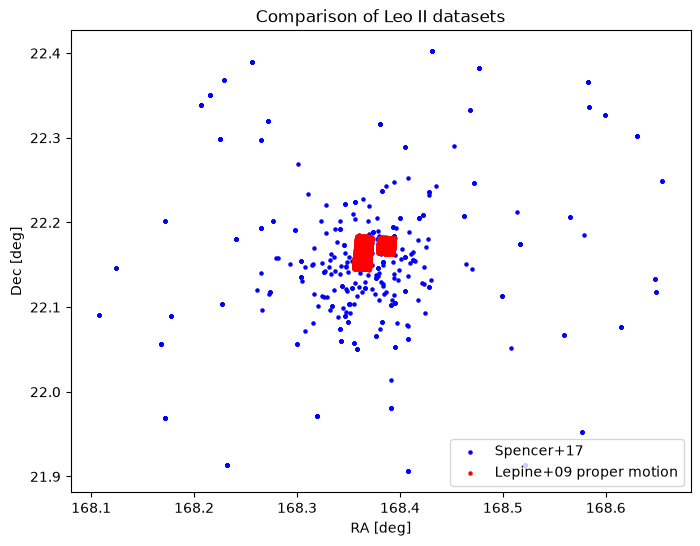

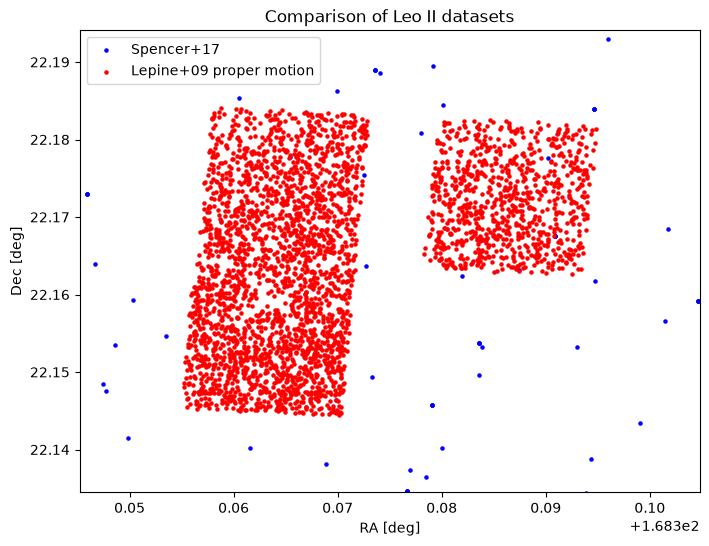

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(spencer_data['ra'], spencer_data['dec'], s=5, c='blue', label='Spencer+17')
ax.scatter(proper_mot_data['ra'], proper_mot_data['dec'], s=5, c='red', label='Lepine+09 proper motion')
ax.set_xlabel('RA [deg]')
ax.set_ylabel('Dec [deg]')
ax.set_title('Comparison of Leo II datasets')
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(spencer_data['ra'], spencer_data['dec'], s=5, c='blue', label='Spencer+17')
ax.scatter(proper_mot_data['ra'], proper_mot_data['dec'], s=5, c='red', label='Lepine+09 proper motion')

ax.set_xlabel('RA [deg]')
ax.set_ylabel('Dec [deg]')
ax.set_title('Comparison of Leo II datasets')
ax.set_xlim(proper_mot_data['ra'].min() - 0.01, proper_mot_data['ra'].max() + 0.01)
ax.set_ylim(proper_mot_data['dec'].min() - 0.01, proper_mot_data['dec'].max() + 0.01)
ax.legend()
plt.show()

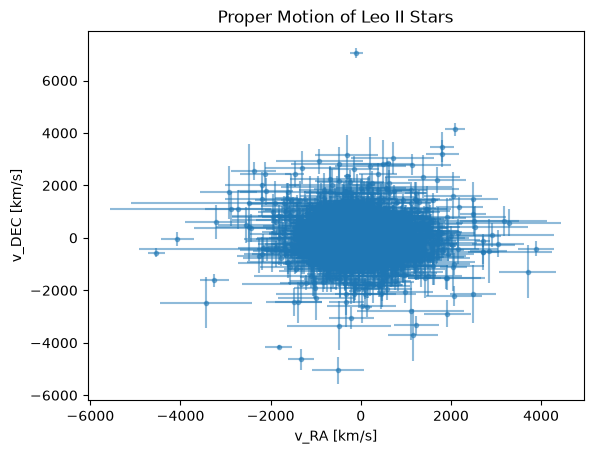

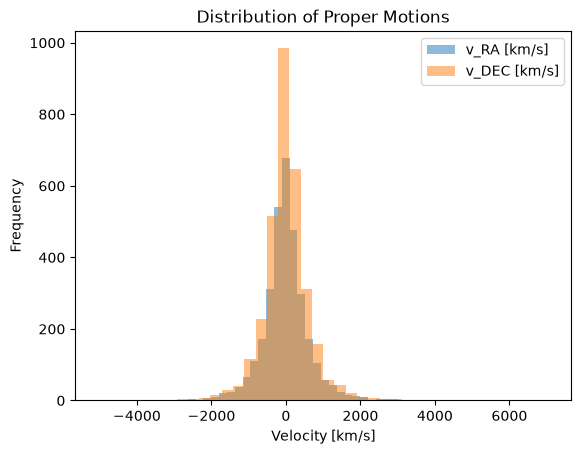

-10.163392163839985 643.746253866116
3.812556615555747 654.2086404877857


In [6]:
RA_PM = proper_mot_data['pmra']
DEC_PM = proper_mot_data['pmdec']
RA_PM_err = proper_mot_data['pmra_err']
DEC_PM_err = proper_mot_data['pmdec_err']






plt.errorbar(RA_PM*masyr_to_kms, DEC_PM*masyr_to_kms, xerr=RA_PM_err*masyr_to_kms, yerr=DEC_PM_err*masyr_to_kms, label='Proper Motion Data', alpha=0.5, linestyle='None', marker='o', markersize=3)
plt.ylabel('v_DEC [km/s]')
plt.xlabel('v_RA [km/s]')
plt.title('Proper Motion of Leo II Stars')
plt.show()

plt.hist(RA_PM*masyr_to_kms, bins=40, alpha=0.5, label='v_RA [km/s]')
plt.hist(DEC_PM*masyr_to_kms, bins=40, alpha=0.5, label='v_DEC [km/s]')
plt.xlabel('Velocity [km/s]')
plt.ylabel('Frequency')
plt.title('Distribution of Proper Motions')
plt.legend()
plt.show()


print(np.mean(RA_PM*masyr_to_kms), np.std(RA_PM*masyr_to_kms))
print(np.mean(DEC_PM*masyr_to_kms), np.std(DEC_PM*masyr_to_kms))

[  0.         -11.05401635 -11.05401635  22.1080327  -11.05401635
 -22.1080327    0.          11.05401635  22.1080327    0.
  22.1080327   11.05401635 -22.1080327   22.1080327 ]


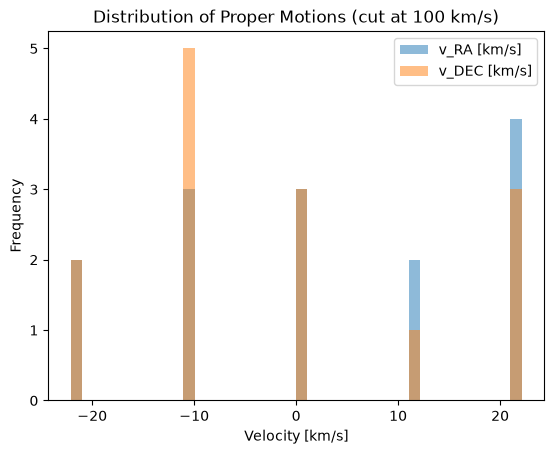

In [7]:
cut = (RA_PM * masyr_to_kms < 25 ) & (DEC_PM * masyr_to_kms < 25) & (RA_PM * masyr_to_kms > -25) & (DEC_PM * masyr_to_kms > -25)
print(RA_PM[cut] * masyr_to_kms)
plt.hist(RA_PM[cut]*masyr_to_kms, bins=40, alpha=0.5, label='v_RA [km/s]')
plt.hist(DEC_PM[cut]*masyr_to_kms, bins=40, alpha=0.5, label='v_DEC [km/s]')
plt.xlabel('Velocity [km/s]')
plt.ylabel('Frequency')
plt.title('Distribution of Proper Motions (cut at 100 km/s)')
plt.legend()
plt.show()

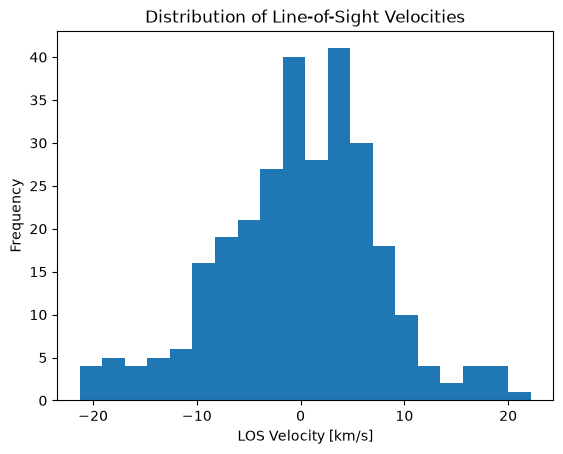

In [20]:
LOS_data = read_spencer_table(spencer_path)

mask = LOS_data['is_member'] == 'Y'

LOS_data = {key: value[mask] for key, value in LOS_data.items()}

v_sys = np.mean(LOS_data['velocity'])

LOS_data['velocity'] -= v_sys

plt.hist(LOS_data['velocity'], bins=20, alpha=1)
plt.xlabel('LOS Velocity [km/s]')
plt.ylabel('Frequency')
plt.title('Distribution of Line-of-Sight Velocities')


plt.show()